# Case 2: Figure Reproduction Notebook

This notebook is for loading precomputed MOSAIC outputs and generating case-study figures only.

For full analysis/statistical workflow details, see the analysis pipeline and mixed effects models notebooks.

In [8]:
# --- 1. Load Precomputed Data ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root
ROOT = Path.cwd().parents[1] if Path.cwd().name == "MOSAIC" else Path.cwd()

# Figure sources
linear_file = ROOT / ".." / "linear_results" / "linear_arms_mag.csv"
rqa_file = ROOT / ".." / "crqa_results" / "crqa_arms_mag.csv"

if not linear_file.exists():
    raise FileNotFoundError(f"Missing linear figure source: {linear_file}")
if not rqa_file.exists():
    raise FileNotFoundError(f"Missing RQA figure source: {rqa_file}")

lin_df = pd.read_csv(linear_file)
rqa_wide = pd.read_csv(rqa_file)

lin_df['Condition'] = pd.Categorical(
    lin_df['Condition'].astype(str).str.strip(),
    categories=['Office', 'Cafe', 'Food', 'Party'],
    ordered=True,
)
rqa_wide['Condition'] = pd.Categorical(
    rqa_wide['Condition'].astype(str).str.strip(),
    categories=['Office', 'Cafe', 'Food', 'Party'],
    ordered=True,
)

print(f"Loaded Linear shape: {lin_df.shape}")
print(f"Loaded RQA shape: {rqa_wide.shape}")

Loaded Linear shape: (6344, 17)
Loaded RQA shape: (2462, 17)


C:\Users\Cathy\AppData\Local\Temp\ipykernel_42332\1913565821.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
C:\Users\Cathy\AppData\Local\Temp\ipykernel_42332\1913565821.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Cathy\AppData\Local\Temp\ipykernel_42332\1913565821.py:48: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
C:\Users\Cathy\AppData\Local\Temp\ipykernel_42332\1913565821.py:48: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(
C:\Users\Cathy\AppData\Local\Temp\ipykernel_42332\1913565821.py:88: UserWa

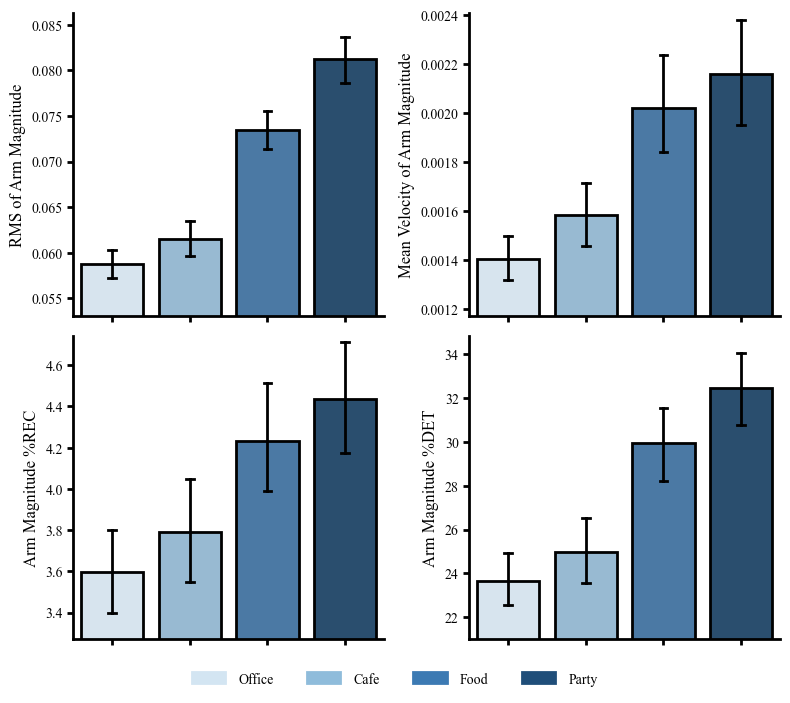

In [12]:
# --- 2. CSV-Driven Plots Across Conditions (Requested Metrics) ---
import matplotlib as mpl
import matplotlib.font_manager as fm

plt.style.use('default')

# Windows-safe: use installed font name first
plt.rcParams["font.family"] = ["Times New Roman", "serif"]

# Optional: explicitly add Windows Times New Roman file if present
tnr_path = Path(r"C:\Windows\Fonts\times.ttf")
if tnr_path.exists():
    fm.fontManager.addfont(str(tnr_path))

tnr_fp = fm.FontProperties(fname=str(tnr_path))
tnr_name = tnr_fp.get_name()

# Apply font settings AFTER style so they are not overwritten
mpl.rcParams['font.family'] = [tnr_name]
mpl.rcParams['font.serif'] = [tnr_name, 'Times', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['svg.fonttype'] = 'path'   # outlines for SVG
mpl.rcParams['pdf.fonttype'] = 42        # embed TrueType in PDF

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()
colors = ['#d3e5f2', '#8fbcdb', '#3c7ab3', '#1f4e79']

plot_specs = [
    (lin_df, 'RMS', 'RMS of Arm Magnitude', axes[0]),
    (lin_df, 'MeanVel', 'Mean Velocity of Arm Magnitude', axes[1]),
    (rqa_wide, 'CRQA_REC', 'Arm Magnitude %REC', axes[2]),
    (rqa_wide, 'CRQA_DET', 'Arm Magnitude %DET', axes[3]),
]

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
    for c, l in zip(colors, ['Office', 'Cafe', 'Food', 'Party'])
]

for df_plot, metric, ylab, ax in plot_specs:
    if metric not in df_plot.columns:
        ax.text(0.5, 0.5, f'Missing:\n{metric}', ha='center', va='center', fontproperties=tnr_fp)
        ax.set_axis_off()
        continue

    sns.barplot(
        data=df_plot,
        x='Condition',
        y=metric,
        order=['Office', 'Cafe', 'Food', 'Party'],
        ax=ax,
        palette=colors,
        edgecolor='black',
        linewidth=2,
        capsize=0.1,
        errcolor='black',
        errwidth=2,
    )

    # Give headroom so SEM caps don't hit bounds
    ax.margins(y=0.15)

    # Ensure error bars/caps are not clipped at axes boundary
    for line in ax.lines:
        line.set_clip_on(False)

    stats = (
        df_plot.loc[df_plot['Condition'].isin(['Office', 'Cafe', 'Food', 'Party']), ['Condition', metric]]
        .dropna()
        .groupby('Condition', observed=True)[metric]
        .agg(['mean', 'sem'])
        .reindex(['Office', 'Cafe', 'Food', 'Party'])
    )
    stats['sem'] = stats['sem'].fillna(0)

    if stats['mean'].notna().any():
        low = (stats['mean'] - stats['sem']).min()
        high = (stats['mean'] + stats['sem']).max()
        span = max(high - low, 1e-6)
        lower_pad = 0.20 * span
        upper_pad = 0.15 * span
        ax.set_ylim(low - lower_pad, high + upper_pad)

    ax.set_ylabel(ylab, fontsize=12, fontproperties=tnr_fp)
    ax.set_xlabel('')
    ax.set_xticklabels(['', '', '', ''])
    ax.tick_params(axis='x', length=4, width=2)
    ax.tick_params(axis='y', length=4, width=2)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontproperties(tnr_fp)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

legend = fig.legend(
    handles=legend_patches,
    labels=['Office', 'Cafe', 'Food', 'Party'],
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=12,
    frameon=False,
)
for txt in legend.get_texts():
    txt.set_fontproperties(tnr_fp)

out_svg = ROOT / 'figs' / 'linear_rqa_summary_mosaic.svg'
out_pdf = ROOT / 'figs' / 'linear_rqa_summary_mosaic.pdf'
plt.savefig(out_svg, dpi=300, bbox_inches='tight')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()